# Balance-Guided Oblique Trees with Signed Spectral Clustering

This notebook demonstrates the FIGS (Fast Interpretable Greedy-tree Sums) algorithm with
Co-Information (CoI) guided feature clustering for oblique decision tree splits.

**What it does:**
1. Computes a Co-Information matrix between features and the target
2. Clusters features using spectral methods (unsigned, signed/SPONGE, hard-threshold)
3. Trains FIGS trees using cluster-guided oblique splits
4. Compares 5 split strategies via cross-validation: axis-aligned, random-oblique, unsigned-spectral, signed-spectral, hard-threshold

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab (always install everywhere)
# (none needed for this demo)

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy==1.16.3 on Colab (Python 3.12); use 1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    import platform
    _scipy = 'scipy==1.16.3' if tuple(int(x) for x in platform.python_version_tuple()[:2]) >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import os
import time
import warnings
from collections import defaultdict
from itertools import combinations

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.linear_model import RidgeCV
from sklearn.metrics import (
    balanced_accuracy_score,
    mutual_info_score,
    r2_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.preprocessing import KBinsDiscretizer

print('All imports successful.')

All imports successful.


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7dffcf-balance-guided-oblique-trees-signed-spec/main/experiment_iter5_re_run_real_ben/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  adult: 60 examples


## Configuration

All tunable parameters for the experiment. Set to small values for a quick demo.

In [5]:
# --- Demo Configuration ---
METHODS = ["axis_aligned", "random_oblique", "unsigned_spectral", "signed_spectral", "hard_threshold"]
MAX_SPLITS_VALUES = [5, 10, 20]    # Full original values
PREDICT_MAX_SPLITS = 10
COI_SUBSAMPLE_N = 20000            # Full original value
MI_N_BINS = 10
print(f"Methods: {METHODS}")
print(f"Max splits values: {MAX_SPLITS_VALUES}")
print(f"CoI subsample N: {COI_SUBSAMPLE_N}")

Methods: ['axis_aligned', 'random_oblique', 'unsigned_spectral', 'signed_spectral', 'hard_threshold']
Max splits values: [5, 10, 20]
CoI subsample N: 20000


## Parse Dataset

Convert raw JSON examples into numpy arrays (X, y, folds) for model training.

In [6]:
def parse_dataset(name, examples):
    """Parse raw examples into numpy arrays."""
    if not examples:
        raise ValueError(f"No examples for {name}")
    first_input = json.loads(examples[0]["input"]) if isinstance(examples[0]["input"], str) else examples[0]["input"]
    feature_names = list(first_input.keys())
    n = len(examples)
    d = len(feature_names)
    X = np.zeros((n, d), dtype=np.float64)
    y = np.zeros(n, dtype=np.float64)
    folds = np.zeros(n, dtype=int)
    task_type = examples[0].get("metadata_task_type", "classification")
    n_classes = examples[0].get("metadata_n_classes", 2)
    for i, ex in enumerate(examples):
        inp = json.loads(ex["input"]) if isinstance(ex["input"], str) else ex["input"]
        for j, fn in enumerate(feature_names):
            try: X[i, j] = float(inp.get(fn, 0.0))
            except (ValueError, TypeError): X[i, j] = 0.0
        y[i] = int(float(ex["output"])) if task_type != "regression" else float(ex["output"])
        folds[i] = int(ex.get("metadata_fold", 0))
    nan_mask = ~np.isfinite(X)
    if nan_mask.any():
        X[nan_mask] = 0.0
    print(f"  {name}: n={n}, d={d}, task={task_type}, classes={n_classes}, folds={list(np.unique(folds).astype(int))}")
    return {"X": X, "y": y, "folds": folds, "feature_names": feature_names,
            "task_type": task_type, "n_classes": n_classes, "examples": examples}

# Parse all datasets from loaded data
datasets = {}
for ds_entry in data['datasets']:
    ds_name = ds_entry['dataset']
    datasets[ds_name] = parse_dataset(ds_name, ds_entry['examples'])
print(f"\nParsed {len(datasets)} dataset(s): {list(datasets.keys())}")

  adult: n=60, d=6, task=classification, classes=2, folds=[np.int64(0), np.int64(1), np.int64(2)]

Parsed 1 dataset(s): ['adult']


## Co-Information (CoI) Matrix Computation

Computes the CoI matrix: `CoI(Xi,Xj;Y) = MI(Xi;Y) + MI(Xj;Y) - MI(Xi,Xj;Y)`.
Positive values indicate redundancy between features; negative values indicate synergy.

In [7]:
def _discretize_y(y, n_bins=10):
    unique = np.unique(y)
    if len(unique) > 20:
        try:
            kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
            return kbd.fit_transform(y.reshape(-1, 1)).ravel().astype(int)
        except ValueError:
            edges = np.linspace(y.min(), y.max(), n_bins + 1)
            return np.digitize(y, edges[1:-1]).astype(int)
    return y.astype(int)

def _bin_feature(x, n_bins=10):
    if np.std(x) < 1e-10:
        return np.zeros(len(x), dtype=int)
    try:
        kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
        return kbd.fit_transform(x.reshape(-1, 1)).ravel().astype(int)
    except ValueError:
        return np.zeros(len(x), dtype=int)

def compute_coi_matrix(X_sub, y_sub, n_bins=10):
    """Compute d x d Co-Information matrix via binning-based MI."""
    n, d = X_sub.shape
    pairs = [(i, j) for i in range(d) for j in range(i + 1, d)]
    y_disc = _discretize_y(y_sub, n_bins)
    binned = np.zeros((n, d), dtype=int)
    for i in range(d):
        binned[:, i] = _bin_feature(X_sub[:, i], n_bins)
    mi_individual = np.array([mutual_info_score(binned[:, i], y_disc) for i in range(d)])
    mi_joint_vals = []
    for i, j in pairs:
        combined = binned[:, i] * n_bins + binned[:, j]
        mi_joint_vals.append(mutual_info_score(combined, y_disc))
    CoI = np.zeros((d, d))
    for idx, (i, j) in enumerate(pairs):
        coi_val = mi_individual[i] + mi_individual[j] - mi_joint_vals[idx]
        CoI[i, j] = coi_val
        CoI[j, i] = coi_val
    return CoI, mi_individual

print('CoI functions defined.')

CoI functions defined.


## Feature Clustering Methods

Three clustering approaches applied to the CoI matrix:
- **Unsigned spectral**: Clusters features using |CoI| as affinity
- **Signed spectral (SPONGE)**: Preserves sign structure (redundancy vs synergy)
- **Hard threshold**: Binary graph from top-percentile |CoI| entries

In [8]:
def unsigned_spectral_clustering(CoI_matrix, max_k=10):
    d = CoI_matrix.shape[0]
    if d < 3:
        return [list(range(d))], 1, np.zeros(d, dtype=int)
    max_k = min(max_k, d - 1)
    affinity = np.abs(CoI_matrix.copy())
    np.fill_diagonal(affinity, 0)
    degree = affinity.sum(axis=1)
    degree_safe = np.maximum(degree, 1e-10)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree_safe))
    L = np.diag(degree) - affinity
    L_norm = D_inv_sqrt @ L @ D_inv_sqrt
    try:
        eigenvalues = np.sort(np.real(eigh(L_norm, eigvals_only=True)))
    except Exception:
        return [list(range(d))], 1, np.zeros(d, dtype=int)
    n_eig = min(max_k + 1, len(eigenvalues))
    gaps = np.diff(eigenvalues[1:n_eig])
    if len(gaps) == 0:
        return [list(range(d))], 1, np.zeros(d, dtype=int)
    k_eigengap = max(2, min(int(np.argmax(gaps) + 2), max_k))
    best_k, best_score, best_labels = k_eigengap, -1.0, None
    for k_try in range(max(2, k_eigengap - 1), min(max_k + 1, k_eigengap + 2)):
        try:
            sc = SpectralClustering(n_clusters=k_try, affinity="precomputed", random_state=42, n_init=10)
            labels = sc.fit_predict(affinity)
            if len(np.unique(labels)) > 1:
                sil = silhouette_score(affinity, labels, metric="precomputed")
                if sil > best_score:
                    best_k, best_score, best_labels = k_try, sil, labels
        except Exception: continue
    if best_labels is None:
        try:
            sc = SpectralClustering(n_clusters=k_eigengap, affinity="precomputed", random_state=42, n_init=10)
            best_labels = sc.fit_predict(affinity)
            best_k = k_eigengap
        except Exception:
            return [list(range(d))], 1, np.zeros(d, dtype=int)
    modules = [list(np.where(best_labels == c)[0]) for c in range(best_k) if np.sum(best_labels == c) >= 2]
    if not modules: modules = [list(range(d))]
    return modules, best_k, best_labels

def sponge_sym_clustering(CoI_matrix, tau=1.0, max_k=10):
    d = CoI_matrix.shape[0]
    if d < 3:
        return [list(range(d))], 1, np.zeros(d, dtype=int), 0.0
    max_k = min(max_k, d - 1)
    W_pos = np.maximum(CoI_matrix, 0).copy()
    W_neg = np.abs(np.minimum(CoI_matrix, 0))
    np.fill_diagonal(W_pos, 0); np.fill_diagonal(W_neg, 0)
    D_pos = np.diag(W_pos.sum(axis=1)); D_neg = np.diag(W_neg.sum(axis=1))
    L_pos = D_pos - W_pos; L_neg = D_neg - W_neg
    A = L_pos + tau * D_neg
    B = L_neg + tau * D_pos + 1e-6 * np.eye(d)
    try:
        eigenvalues, eigenvectors = eigh(A, B)
    except Exception:
        try:
            B += 1e-4 * np.eye(d)
            eigenvalues, eigenvectors = eigh(A, B)
        except Exception:
            modules, k, labels = unsigned_spectral_clustering(CoI_matrix, max_k)
            return modules, k, labels, 0.0
    sorted_idx = np.argsort(eigenvalues)
    sorted_evals = eigenvalues[sorted_idx]
    n_eig = min(max_k + 1, len(sorted_evals))
    gaps = np.diff(sorted_evals[1:n_eig])
    k_eigengap = max(2, min(int(np.argmax(gaps) + 2) if len(gaps) > 0 else 2, max_k))
    V = eigenvectors[:, sorted_idx[:k_eigengap]]
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    V_norm = V / np.maximum(norms, 1e-10)
    km = KMeans(n_clusters=k_eigengap, random_state=42, n_init=10)
    labels = km.fit_predict(V_norm)
    W_signed = W_pos - W_neg
    D_abs = np.diag(np.abs(W_signed).sum(axis=1))
    L_signed = D_abs - W_signed
    try:
        frust_evals = np.sort(np.real(eigh(L_signed, eigvals_only=True)))
        frustration = float(frust_evals[0])
    except Exception: frustration = 0.0
    modules = [list(np.where(labels == c)[0]) for c in range(k_eigengap) if np.sum(labels == c) >= 2]
    if not modules: modules = [list(range(d))]
    return modules, k_eigengap, labels, frustration

def hard_threshold_clustering(CoI_matrix, percentile=90):
    d = CoI_matrix.shape[0]
    if d < 3:
        return [list(range(d))], 1, np.zeros(d, dtype=int)
    abs_coi = np.abs(CoI_matrix.copy())
    np.fill_diagonal(abs_coi, 0)
    nonzero = abs_coi[abs_coi > 0]
    if len(nonzero) == 0:
        return [list(range(d))], 1, np.zeros(d, dtype=int)
    threshold = np.percentile(nonzero, percentile)
    adj = (abs_coi >= threshold).astype(float)
    n_comp, labels = connected_components(csr_matrix(adj), directed=False)
    modules = [list(np.where(labels == c)[0]) for c in range(n_comp) if np.sum(labels == c) >= 2]
    if not modules: modules = [list(range(d))]
    return modules, n_comp, labels

print('Clustering functions defined.')

Clustering functions defined.


## FIGS Model

Greedy-tree model with pluggable split strategies:
- **axis_aligned**: Standard single-feature splits (baseline)
- **random_oblique**: Random multi-feature subsets with Ridge projection
- **unsigned/signed/hard_threshold**: CoI-module-guided oblique splits

In [9]:
class FIGSNode:
    __slots__ = ["feature_indices", "coefs", "threshold", "left", "right", "value", "is_leaf", "n_samples"]
    def __init__(self):
        self.feature_indices = None; self.coefs = None; self.threshold = None
        self.left = None; self.right = None; self.value = 0.0; self.is_leaf = True; self.n_samples = 0

class FIGSModel:
    def __init__(self, max_splits=10, split_strategy="axis_aligned", feature_modules=None,
                 task_type="classification", random_state=42):
        self.max_splits = max_splits
        self.split_strategy = split_strategy
        self.feature_modules = feature_modules or []
        self.task_type = task_type
        self.random_state = random_state
        self.root = None; self.splits_used = 0; self.split_arities = []

    def _get_candidates(self, d):
        raw = []
        if self.split_strategy == "axis_aligned":
            raw = [[i] for i in range(d)]
        elif self.split_strategy == "random_oblique":
            import random
            rng = random.Random(self.random_state)
            n_cands = min(50, d * 2)
            for _ in range(n_cands):
                size = rng.randint(2, min(5, d))
                raw.append(sorted(rng.sample(range(d), size)))
            raw.extend([[i] for i in range(d)])
        elif self.split_strategy in ("unsigned_spectral", "signed_spectral", "hard_threshold"):
            for module in self.feature_modules:
                if len(module) >= 2:
                    raw.append(list(module))
                    if len(module) <= 6:
                        for pair in combinations(module, 2):
                            raw.append(list(pair))
            raw.extend([[i] for i in range(d)])
        else:
            raw = [[i] for i in range(d)]
        seen = set(); unique = []
        for c in raw:
            key = tuple(c)
            if key not in seen: seen.add(key); unique.append(c)
        return unique

    def _evaluate_split(self, X, y, indices, feat_subset):
        n = len(indices)
        if n < 10: return None, None, -np.inf
        y_sub = y[indices]; total_var = np.var(y_sub) * n
        if total_var < 1e-12: return None, None, -np.inf
        if len(feat_subset) == 1:
            proj = X[indices, feat_subset[0]]; coefs = np.array([1.0])
        else:
            X_feat = X[np.ix_(indices, feat_subset)]
            if np.all(X_feat.std(axis=0) < 1e-10): return None, None, -np.inf
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0])
                    ridge.fit(X_feat, y_sub)
                    coefs = ridge.coef_.ravel()
            except Exception: return None, None, -np.inf
            if np.all(np.abs(coefs) < 1e-10): return None, None, -np.inf
            proj = X_feat @ coefs
        if np.std(proj) < 1e-10: return None, None, -np.inf
        thresholds = np.unique(np.percentile(proj, np.arange(10, 100, 10)))
        best_red, best_thresh = -np.inf, None
        for thresh in thresholds:
            left_mask = proj <= thresh
            n_left, n_right = left_mask.sum(), n - left_mask.sum()
            if n_left < 5 or n_right < 5: continue
            red = total_var - (np.var(y_sub[left_mask]) * n_left + np.var(y_sub[~left_mask]) * n_right)
            if red > best_red: best_red, best_thresh = red, thresh
        return coefs, best_thresh, best_red

    def fit(self, X, y):
        n, d = X.shape
        y_work = y.astype(np.float64)
        self.root = FIGSNode(); self.root.value = float(np.mean(y_work)); self.root.n_samples = n
        self.splits_used = 0; self.split_arities = []
        candidates = self._get_candidates(d)
        active = [(self.root, np.arange(n, dtype=np.int64))]
        for _ in range(self.max_splits):
            if not active: break
            best_red, best_info = -np.inf, None
            for leaf_idx, (leaf, indices) in enumerate(active):
                if len(indices) < 10: continue
                for feat_sub in candidates:
                    coefs, thresh, red = self._evaluate_split(X, y_work, indices, feat_sub)
                    if red > best_red and thresh is not None:
                        best_red, best_info = red, (leaf_idx, feat_sub, coefs, thresh)
            if best_info is None or best_red <= 1e-10: break
            leaf_idx, feat_sub, coefs, thresh = best_info
            leaf, indices = active[leaf_idx]
            leaf.is_leaf = False; leaf.feature_indices = list(feat_sub)
            leaf.coefs = coefs; leaf.threshold = thresh
            self.split_arities.append(len(feat_sub)); self.splits_used += 1
            proj = X[indices, feat_sub[0]] if len(feat_sub) == 1 else X[np.ix_(indices, feat_sub)] @ coefs
            left_mask = proj <= thresh
            left_idx, right_idx = indices[left_mask], indices[~left_mask]
            leaf.left = FIGSNode()
            leaf.left.value = float(np.mean(y_work[left_idx])) if len(left_idx) > 0 else leaf.value
            leaf.left.n_samples = len(left_idx)
            leaf.right = FIGSNode()
            leaf.right.value = float(np.mean(y_work[right_idx])) if len(right_idx) > 0 else leaf.value
            leaf.right.n_samples = len(right_idx)
            active = [a for i, a in enumerate(active) if i != leaf_idx]
            if len(left_idx) >= 10: active.append((leaf.left, left_idx))
            if len(right_idx) >= 10: active.append((leaf.right, right_idx))
        return self

    def _predict_batch(self, node, X, indices, preds):
        if len(indices) == 0: return
        if node.is_leaf or node.left is None or node.right is None:
            preds[indices] = node.value; return
        proj = X[indices, node.feature_indices[0]] if len(node.feature_indices) == 1 else X[np.ix_(indices, node.feature_indices)] @ node.coefs
        left_mask = proj <= node.threshold
        self._predict_batch(node.left, X, indices[left_mask], preds)
        self._predict_batch(node.right, X, indices[~left_mask], preds)

    def predict(self, X):
        n = X.shape[0]; preds = np.full(n, self.root.value if self.root else 0.0)
        if self.root is not None:
            self._predict_batch(self.root, X, np.arange(n, dtype=np.int64), preds)
        if self.task_type in ("classification", "binary_classification"): return (preds >= 0.5).astype(int)
        return preds

    def predict_raw(self, X):
        n = X.shape[0]; preds = np.full(n, self.root.value if self.root else 0.0)
        if self.root is not None:
            self._predict_batch(self.root, X, np.arange(n, dtype=np.int64), preds)
        return preds

    def get_metrics(self):
        depths = []; self._collect_depths(self.root, 0, depths)
        return {"total_splits": self.splits_used,
                "avg_split_arity": round(float(np.mean(self.split_arities)), 4) if self.split_arities else 1.0,
                "avg_path_length": round(float(np.mean(depths)), 4) if depths else 0.0}

    def _collect_depths(self, node, depth, depths):
        if node is None: return
        if node.is_leaf: depths.append(depth); return
        self._collect_depths(node.left, depth + 1, depths)
        self._collect_depths(node.right, depth + 1, depths)

print('FIGSModel defined.')

FIGSModel defined.


## Run Experiment

For each dataset: compute CoI, cluster features, then run all FIGS variants with cross-validation.

In [10]:
all_results = []
summary_results = []
clustering_info = {}

for ds_name, ds in datasets.items():
    X, y, folds_arr = ds["X"], ds["y"], ds["folds"]
    task_type = ds["task_type"]
    n, d = X.shape
    print(f"\n{'='*50}")
    print(f"Dataset: {ds_name} (n={n}, d={d}, task={task_type})")
    print(f"{'='*50}")

    # --- CoI Computation ---
    t_coi = time.time()
    n_sub = min(n, COI_SUBSAMPLE_N)
    rng = np.random.RandomState(42)
    sub_idx = rng.choice(n, n_sub, replace=False)
    feat_std = X[sub_idx].std(axis=0)
    valid_feats = np.where(feat_std > 1e-10)[0]

    if len(valid_feats) < 2:
        CoI_full = np.zeros((d, d)); mi_full = np.zeros(d)
    else:
        CoI_sub, mi_sub = compute_coi_matrix(X[sub_idx][:, valid_feats], y[sub_idx], n_bins=MI_N_BINS)
        CoI_full = np.zeros((d, d)); mi_full = np.zeros(d)
        for i_idx, vi in enumerate(valid_feats):
            mi_full[vi] = mi_sub[i_idx]
            for j_idx, vj in enumerate(valid_feats):
                CoI_full[vi, vj] = CoI_sub[i_idx, j_idx]
    print(f"  CoI computed in {time.time()-t_coi:.2f}s (valid features: {len(valid_feats)})")

    # --- Clustering ---
    CoI_v = CoI_full[np.ix_(valid_feats, valid_feats)] if len(valid_feats) >= 2 else CoI_full
    us_mod_sub, us_k, us_lab = unsigned_spectral_clustering(CoI_v)
    ss_mod_sub, ss_k, ss_lab, frust = sponge_sym_clustering(CoI_v)
    ht_mod_sub, ht_k, ht_lab = hard_threshold_clustering(CoI_v)

    if len(valid_feats) >= 2:
        us_modules = [[int(valid_feats[i]) for i in m] for m in us_mod_sub]
        ss_modules = [[int(valid_feats[i]) for i in m] for m in ss_mod_sub]
        ht_modules = [[int(valid_feats[i]) for i in m] for m in ht_mod_sub]
    else:
        us_modules = ss_modules = ht_modules = [list(range(d))]

    print(f"  Unsigned: k={us_k}, sizes={[len(m) for m in us_modules]}")
    print(f"  Signed:   k={ss_k}, sizes={[len(m) for m in ss_modules]}, frust={frust:.4f}")
    print(f"  HardThresh: k={ht_k}, sizes={[len(m) for m in ht_modules]}")

    clustering_info[ds_name] = {
        "unsigned_k": us_k, "signed_k": ss_k, "hardthresh_k": ht_k, "frustration": round(frust, 6)
    }

    module_map = {
        "unsigned_spectral": us_modules, "signed_spectral": ss_modules,
        "hard_threshold": ht_modules, "axis_aligned": None, "random_oblique": None,
    }
    unique_folds = sorted(np.unique(folds_arr).astype(int))

    # --- Cross-Validation ---
    for method in METHODS:
        modules = module_map[method]
        for max_splits in MAX_SPLITS_VALUES:
            fold_metrics = []
            t_method = time.time()
            for fold_id in unique_folds:
                test_mask = folds_arr == fold_id
                X_tr, y_tr = X[~test_mask], y[~test_mask]
                X_te, y_te = X[test_mask], y[test_mask]
                try:
                    model = FIGSModel(max_splits=max_splits, split_strategy=method,
                                     feature_modules=modules, task_type=task_type,
                                     random_state=int(42 + fold_id))
                    model.fit(X_tr, y_tr)
                    y_pred = model.predict(X_te)
                    fold_result = {"dataset": ds_name, "method": method, "max_splits": max_splits,
                                   "fold": int(fold_id), "n_train": len(X_tr), "n_test": len(X_te),
                                   "task_type": task_type}
                    if task_type in ("classification", "binary_classification"):
                        fold_result["balanced_accuracy"] = round(float(balanced_accuracy_score(y_te, y_pred)), 6)
                        try:
                            y_raw = model.predict_raw(X_te)
                            if len(np.unique(y_te)) == 2:
                                fold_result["auc"] = round(float(roc_auc_score(y_te, y_raw)), 6)
                        except Exception: pass
                    else:
                        fold_result["r2"] = round(float(r2_score(y_te, y_pred)), 6)
                    tree_met = model.get_metrics()
                    fold_result.update(tree_met)
                    all_results.append(fold_result)
                    fold_metrics.append(fold_result)
                except Exception as e:
                    print(f"    Error: {method} s={max_splits} fold={fold_id}: {e}")
                finally:
                    gc.collect()

            # Summary
            summary = {"dataset": ds_name, "method": method, "max_splits": max_splits}
            for key in ["balanced_accuracy", "auc", "r2", "total_splits", "avg_split_arity", "avg_path_length"]:
                vals = [fr[key] for fr in fold_metrics if key in fr and fr.get(key) is not None]
                if vals:
                    summary[f"{key}_mean"] = round(float(np.mean(vals)), 6)
                    summary[f"{key}_std"] = round(float(np.std(vals)), 6)
            summary["time_s"] = round(time.time() - t_method, 2)
            summary_results.append(summary)
            prim = summary.get("balanced_accuracy_mean", summary.get("r2_mean"))
            if prim is not None:
                print(f"  {method:20s} s={max_splits:2d}: {prim:.4f} ({summary['time_s']:.1f}s)")

print(f"\nTotal fold results: {len(all_results)}")
print(f"Total summaries: {len(summary_results)}")


Dataset: adult (n=60, d=6, task=classification)
  CoI computed in 0.06s (valid features: 6)


/ai-inventor/aii_pipeline/runs/jamnik-sgfigs-pid-v2/4_gen_paper_repo/notebook_workspaces/exp_id1_it5__opus/.nb_env/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/ai-inventor/aii_pipeline/runs/jamnik-sgfigs-pid-v2/4_gen_paper_repo/notebook_workspaces/exp_id1_it5__opus/.nb_env/lib/python3.10/site-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


  Unsigned: k=4, sizes=[3]
  Signed:   k=5, sizes=[2], frust=0.2868
  HardThresh: k=4, sizes=[3]
  axis_aligned         s= 5: 0.7434 (0.2s)


  axis_aligned         s=10: 0.7434 (0.1s)
  axis_aligned         s=20: 0.7434 (0.1s)


  random_oblique       s= 5: 0.7719 (0.2s)


...

  random_oblique       s=20: 0.7719 (0.2s)
  unsigned_spectral    s= 5: 0.6485 (0.2s)


  unsigned_spectral    s=10: 0.6485 (0.2s)
  unsigned_spectral    s=20: 0.6485 (0.2s)


  signed_spectral      s= 5: 0.7283 (0.1s)
  signed_spectral      s=10: 0.7283 (0.1s)


  signed_spectral      s=20: 0.7283 (0.1s)
  hard_threshold       s= 5: 0.6485 (0.2s)


  hard_threshold       s=10: 0.6485 (0.2s)
  hard_threshold       s=20: 0.6485 (0.2s)

Total fold results: 45
Total summaries: 15


## Results Visualization

Compare balanced accuracy across all 5 FIGS split strategies.


RESULTS SUMMARY
Method                 MaxSplits  BalAcc_mean  BalAcc_std  Splits   Arity
--------------------------------------------------------------------------------
axis_aligned                   5       0.7434      0.0636     5.0    1.00
axis_aligned                  10       0.7434      0.0636     5.0    1.00
axis_aligned                  20       0.7434      0.0636     5.0    1.00
random_oblique                 5       0.7719      0.0811     3.7    3.03
random_oblique                10       0.7719      0.0811     3.7    3.03
random_oblique                20       0.7719      0.0811     3.7    3.03
unsigned_spectral              5       0.6485      0.1262     4.7    2.37
unsigned_spectral             10       0.6485      0.1262     4.7    2.37
unsigned_spectral             20       0.6485      0.1262     4.7    2.37
signed_spectral                5       0.7283      0.0769     5.0    1.13
signed_spectral               10       0.7283      0.0769     5.3    1.12
signed_spectra

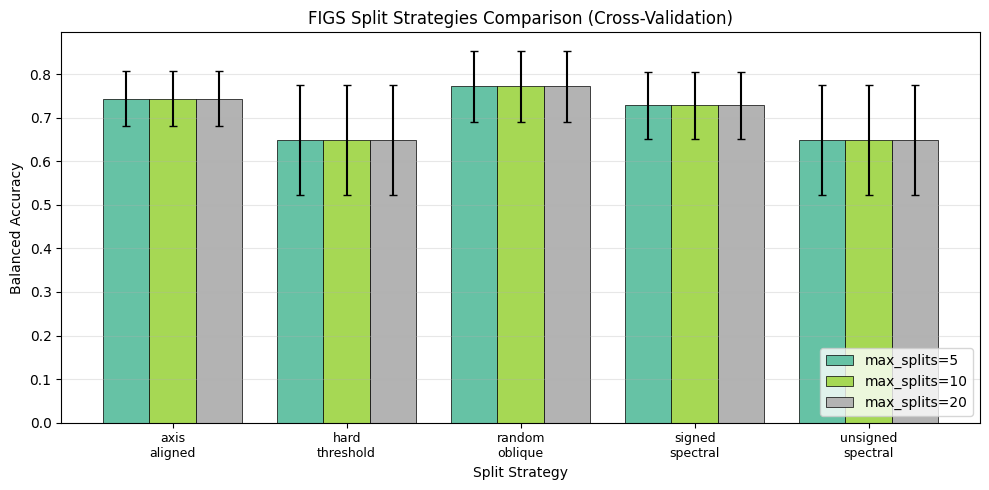


Demo complete!


In [11]:
# --- Results Table ---
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"{'Method':<22} {'MaxSplits':>9} {'BalAcc_mean':>12} {'BalAcc_std':>11} {'Splits':>7} {'Arity':>7}")
print("-"*80)
for s in summary_results:
    ba_mean = s.get('balanced_accuracy_mean', s.get('r2_mean', float('nan')))
    ba_std = s.get('balanced_accuracy_std', s.get('r2_std', float('nan')))
    splits = s.get('total_splits_mean', float('nan'))
    arity = s.get('avg_split_arity_mean', float('nan'))
    print(f"{s['method']:<22} {s['max_splits']:>9} {ba_mean:>12.4f} {ba_std:>11.4f} {splits:>7.1f} {arity:>7.2f}")

# --- Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))
methods_in_data = sorted(set(s['method'] for s in summary_results))
max_splits_in_data = sorted(set(s['max_splits'] for s in summary_results))
x = np.arange(len(methods_in_data))
width = 0.8 / max(len(max_splits_in_data), 1)
colors = plt.cm.Set2(np.linspace(0, 1, len(max_splits_in_data)))

for idx, ms in enumerate(max_splits_in_data):
    means, stds = [], []
    for m in methods_in_data:
        match = [s for s in summary_results if s['method'] == m and s['max_splits'] == ms]
        if match:
            means.append(match[0].get('balanced_accuracy_mean', match[0].get('r2_mean', 0)))
            stds.append(match[0].get('balanced_accuracy_std', match[0].get('r2_std', 0)))
        else:
            means.append(0); stds.append(0)
    offset = (idx - len(max_splits_in_data)/2 + 0.5) * width
    ax.bar(x + offset, means, width, yerr=stds, label=f'max_splits={ms}',
           color=colors[idx], edgecolor='black', linewidth=0.5, capsize=3)

ax.set_xlabel('Split Strategy')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('FIGS Split Strategies Comparison (Cross-Validation)')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', '\n') for m in methods_in_data], fontsize=9)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nDemo complete!")